In [5]:
import os
import gc
import sys
import json
import copy
import random
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, Dict, Sequence

from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import Dataset

import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import PreTrainedTokenizerFast
from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model


print("Torch version:{}".format(torch.__version__)) # Torch version:1.12.1
print("Cuda version: {}".format(torch.version.cuda)) # Cuda version: 11.3
print("transformers version: {}".format(transformers.__version__)) # transformers 4.28.0
print("GPU 사용 가능여부: {}".format(torch.cuda.is_available()))

# === Colab 호환 셋업 (자동 추가) ===
torch._orig_load = getattr(torch, '_orig_load', torch.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return torch._orig_load(*a, **k)
torch.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치')


Torch version:2.11.0+cu128
Cuda version: 12.8
transformers version: 5.13.1
GPU 사용 가능여부: True
[colab-compat] torch.load weights_only=False 패치


## 환경 셋업

In [6]:
!pip install datasets
!pip install loralib
!pip install trl

In [7]:
# git clone 안되어있으면 사용
!git clone https://github.com/airobotlab/KoChatGPT

# 코랩 환경에서만 사용
# !cp -r /content/KoChatGPT/colossalai_ChatGPT_230319/chatgpt /content/chatgpt

fatal: destination path 'KoChatGPT' already exists and is not an empty directory.


In [8]:
# !rm -rf chatgpt

In [9]:
git_base_path = "./KoChatGPT/colossalai_ChatGPT_230319/chatgpt"

# chatgpt 패키지의 부모 디렉터리를 sys.path에 추가해야 import chatgpt가 동작합니다.
_chatgpt_parent = os.path.abspath(os.path.dirname(git_base_path))
if _chatgpt_parent not in sys.path:
    sys.path.insert(0, _chatgpt_parent)

modifications = [
    {
        "file": f"{git_base_path}/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = True"},
        ],
    },
    {
        "file": f"{git_base_path}/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": f"{git_base_path}/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": f"{git_base_path}/trainer/base.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": f"{git_base_path}/trainer/rm.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])

⚠️ ./KoChatGPT/colossalai_ChatGPT_230319/chatgpt/trainer/callbacks/save_checkpoint.py 파일의 3번째 줄이 예상과 다릅니다.
   예상: from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy
   실제: from chatgpt.trainer.strategies import Strategy
⚠️ ./KoChatGPT/colossalai_ChatGPT_230319/chatgpt/trainer/callbacks/save_checkpoint.py 파일의 71번째 줄이 예상과 다릅니다.
   예상: only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)
   실제: only_rank0 = True
⚠️ ./KoChatGPT/colossalai_ChatGPT_230319/chatgpt/trainer/callbacks/save_checkpoint.py 수정할 내용이 없습니다.
⚠️ ./KoChatGPT/colossalai_ChatGPT_230319/chatgpt/trainer/strategies/__init__.py 파일의 1번째 줄이 예상과 다릅니다.
   예상: from .colossalai import ColossalAIStrategy
   실제: 
⚠️ ./KoChatGPT/colossalai_ChatGPT_230319/chatgpt/trainer/strategies/__init__.py 파일의 5번째 줄이 예상과 다릅니다.
   예상: __all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']
   실제: __all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']
⚠️ ./KoChatGPT/colossalai_ChatGPT_230319/chatgpt/train

In [10]:
# 만일 아래 모듈이 불러와지지 않는다면 Clone 및 수정을 잘 진행했는지 확인해주세요.
from chatgpt.trainer.strategies import NaiveStrategy

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2',
    bos_token='</s>', eos_token='</s>', unk_token='<unk>',
    pad_token='<pad>', mask_token='<mask>')

# 가드: 클래스명이 아니라 '기능'으로 검증 (transformers 버전에 따라 클래스명이 흔들림)
_s = '불고기용 고기 한우에요?'
_rt = tokenizer.decode(tokenizer.encode(_s))
assert tokenizer.vocab_size == 51200, f"vocab={tokenizer.vocab_size}"
assert '�' not in _rt and '불고기' in _rt, repr(_rt)


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  513MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

In [12]:
def tokenizer_test(tokenizer):
    print(f"토크나이저 입력 최대 토큰 수: {tokenizer.model_max_length}")
    print(f"kogpt-2 config: {model.config.n_positions}")
    print(f"\n{'='*60}")

    # 테스트
    print("=== tokenize result  ===")
    input_txt = "바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."
    tokens = tokenizer(input_txt).tokens()
    input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].numpy()

    pd.options.display.max_columns = 40
    pd.options.display.max_rows = 60
    df = pd.DataFrame([tokens, input_ids[0]], index=["kogpt-2_tokens", "Input_IDs"])

    print(df.head())
    print(f"\n{'='*60}")

    print("=== decoding test ===")
    max_length=128
    print("=== greedy search ===")
    input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
    output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)
    print(tokenizer.decode(output_greedy[0]))
    print(f"\n{'='*60}")

    print("=== beam search ===")
    input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
    output_beam = model.generate(input_ids, max_length=max_length, num_beams=10, no_repeat_ngram_size=2,
                                do_sample=False)
    print(tokenizer.decode(output_beam[0]))
    print(f"\n{'='*60}")

    print("=== beam search + top_k ===")
    output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, temperature=2.0, top_k=50)
    print(tokenizer.decode(output_beam[0]))
    print(f"\n{'='*60}")

    print("=== beam search + top_p ===")
    output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, top_p=0.90)
    print(tokenizer.decode(output_beam[0]))
    print(f"\n{'='*60}")

In [13]:
tokenizer_test(tokenizer=tokenizer)

토크나이저 입력 최대 토큰 수: 1000000000000000019884624838656
kogpt-2 config: 1024

=== tokenize result  ===
                   0     1     2      3      4     5     6     7     8     9   \
kogpt-2_tokens    ▁바람     도   ▁없는   ▁공중에    ▁수직     의    ▁파    문을    ▁내    이며   
Input_IDs       10891  7235  9712  49207  14438  8143  9203  9941  9094  9639   

                  10    11    12     13     14     15    16     17     18  \
kogpt-2_tokens    ▁고     요     히  ▁떨어지는    ▁오동     잎은    ▁누     구의    ▁발자   
Input_IDs       9065  8084  8811  21215  34769  19985  9669  10139  21626   

                  19    20     21   22  
kogpt-2_tokens     취    ▁입     니까    .  
Input_IDs       8408  9241  23775  389  

=== decoding test ===
=== greedy search ===
바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇다면 그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리

=== beam search ===
바람도 없는 공중에 수직의 파

## 데이터셋 확인

In [14]:
data_path_1_SFT = './KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '불고기용 고기 한우에요?',
  'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.",
  'tokens': 193},
 {'prompt': '쓰던 앱이 유료로 전환됐어',
  'completion': "'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.",
  'tokens': 288},
 {'prompt': '여친이랑 다툼',
  'completion': "'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.",
  'tokens': 153}]

In [15]:
data_path_2_RM = './KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

10220


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?',
  'completion_0': 'Allow me to answer your question. I know that you are curious about me.',
  'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.',
  'completion_2': '라이언에게 말했다.',
  'ranking': [2, 1, 0]},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?',
  'completion_0': '개포주공아파트는 다섯 단지로 이루어져 있습니다.',
  'completion_1': '이날 목송에서 구글상위노',
  'completion_2': '개포주공아파트는 총 27개 단지로 이루어져 있습니다.',
  'ranking': [2, 0, 1]},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?',
  'completion_0': 'The diameter of the Metallic domain is bigger than the Hyperonic domain.',
  'completion_1': '이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\\n\\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다는 가정하에, 그 발언을 문제삼은 후보가 누구였는지를 대답하자면, 그 답은 이화선 당시 민주당 대통령 후보가 될 것입니다. 1992년 총선 때, 김영삼 대선후보는 "집값이 오른 노량진역 부근의 부동산 가격은 세월호 폭침 후 \\\'강남 도시재생\\\' 일환으로 상승했다"는 발언을 했습니다. 하지만 이화선 후보는 이 발언을 "전국적으로 경제적 발전이 이루어지지 않은 지방민의 마음을 멀리해지려는 무례한 발언"이라고 비판하며 문

In [16]:
data_path_3_PPO = './KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?'},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?'}]

# Supervised Fine-Tuning

### SFT
이번 스텝에서는 kogpt-2를 instruction dataset으로 SFT를 진행해 보겠습니다.

먼저 필요한 라이브러리들을 불러오겠습니다.

다음으로 모델과 토크나이저를 불러오겠습니다.

In [17]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
from transformers import PreTrainedTokenizerFast
# [수정] AutoTokenizer는 transformers 5.x에서 byte-level(slow) GPT2Tokenizer로 풀려
# 한글이 바이트 단위로 쪼개진 ID로 학습됨 → 생성 결과가 깨지는 원인.
# fast 토크나이저로 고정해 학습~생성 전 구간의 ID 체계를 일치시킨다.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

print(tokenizer)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TokenizersBackend(name_or_path='skt/kogpt2-base-v2', vocab_size=51200, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '</s>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<usr>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<sys>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	7: AddedT

모델 인퍼런스 단계에서 사용할 prompt 딕셔너리 템플릿과 SFT 데이터셋 클래스를 정의하겠습니다.

In [18]:
class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }

        prompt_input = PROMPT_DICT["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [19]:
@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

이제 SFT_dataset 클래스를 사용해 훈련셋을 만들고 data collator 인스턴스를 만들겠습니다.

In [20]:
train_dataset = SFT_dataset(data_path_1_SFT=data_path_1_SFT, tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])

# 과적합 여부를 볼 수 있도록 일부를 eval 셋으로 분리합니다.
eval_ratio = 0.05
eval_size = int(len(train_dataset) * eval_ratio)
train_size = len(train_dataset) - eval_size
train_dataset, eval_dataset = torch.utils.data.random_split(
    train_dataset, [train_size, eval_size], generator=torch.Generator().manual_seed(42)
)
print(f'train: {len(train_dataset)}, eval: {len(eval_dataset)}')

input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  7673, 20479,  8091, 22311,  9036, 30902, 13675,
          375,   378,   378,   378, 41951,   454,  9549, 20549,   383,  8142,
         7192, 14914,   382, 37767, 13753,  8263,  7166,   739,  8352,  7659,
         9594, 25585, 13600,  8022,  9378, 11532,  9887, 11218,  9111, 16691,
        10351, 10561,  9128, 20479,  8091,  9065,  9446,  9036, 28420, 26521,
        10163, 26367,  6958,  9030,  9882, 12317, 25882,  9209, 37194, 10351,
         9036, 12168, 10529, 15989,  9719, 15434, 10552, 11188, 13362,  9036,
        15805, 11300, 11846,  9146, 16691,  9181,  7397, 15806, 13480, 11342,
        17596,  9161, 19996,  9025, 25006, 18595,  9966, 12592, 10751, 11814,
         8711,  9046, 12450,  9117,  7377, 12521,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -10

훈련을 위한 마지막 단계로 Training arguments를 사용해 trainer 클래스를 정의하겠습니다.

In [21]:
os.makedirs("./results", exist_ok=True)
training_args = transformers.TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16=True,
    eval_strategy="steps",
    eval_steps=100,
    logging_steps=100,
    save_strategy="no",
    report_to="none",
    )
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

SFT 훈련을 진행해볼까요? (PPO 비교용 baseline이므로 3epoch까지 돌리면서, eval loss도 같이 확인하겠습니다.)

In [22]:
sft_result_path = "./results/output_1_SFT"
os.makedirs(sft_result_path, exist_ok=True)

In [23]:
trainer.train()
model.save_pretrained(sft_result_path)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
100,3.201696,2.971242
200,3.025312,2.910079
300,2.977443,2.899854
400,2.953432,2.843409
500,2.931427,2.829692
600,2.847032,2.827511
700,2.895280,2.803297
800,2.826699,2.792309
900,2.787943,2.776310
1000,2.797857,2.762093


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

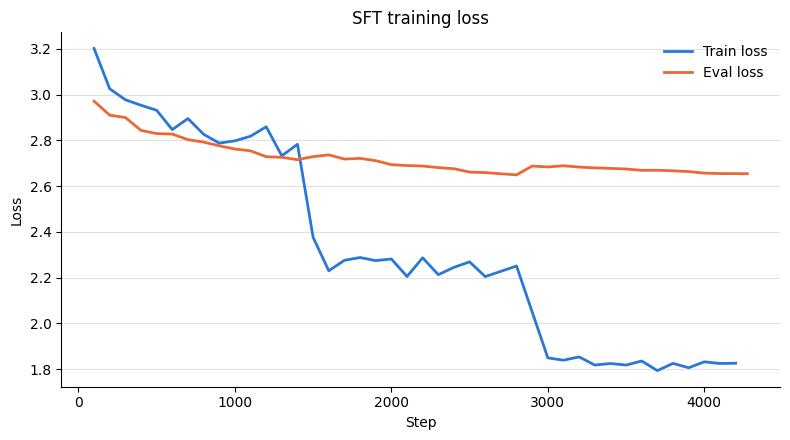

In [24]:
log_history = trainer.state.log_history
train_steps = [x['step'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(train_steps, train_losses, color='#2a78d6', linewidth=2, label='Train loss')
ax.plot(eval_steps, eval_losses, color='#eb6834', linewidth=2, label='Eval loss')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('SFT training loss')
ax.set_axisbelow(True)
ax.grid(True, axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

loss가 잘 줄어들었나요?  
이제 문장 생성 능력을 확인하기 위해 빠르게 허깅페이스의 pipleline 클래스를 사용하여 generator를 만들어보겠습니다.

In [25]:
generator = transformers.pipeline('text-generation', model=sft_result_path, tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['불고기용 고기 한우에요?',
               '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
               '시카고 오헤어 국제공항은 어디에 있어?',
               '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)
for prompt, result in zip(list_prompt, list_result):
    print()
    print((result[0]['generated_text']))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'no_repeat_ngram_size', 'eos_token_id', 'num_beams', 'do_sample', 'repetition_penalty', 'max_new_tokens', 'early_stopping', 'top_k'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 AI 어시스턴트이기 때문에 직접 고기를 판매하지는 않습니다. 하지만 일반적으로 불고기용 고기는 소고기, 돼지고기, 닭고기 등 다양한 부위를 사용합니다. 따라서 해당 부위를 판매하는 가게나 음식점에 문의하시는 것이 좋을 것 같습니다.ックー

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'리처드 닉슨은 41대 부통령직을 수행하지 않았습니다. 리처드 닉슨은 46대 부통령을 수행한 적이 없습니다.: "리처드 닉슨: 41대 부통령직 수행 년도는 알려지지 않았습니다.", 'token': 107}: 57}: 53}: 47

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):'저는 인공지능 어시스턴트이기 때문에 시카고에 대한 정보를 가지고 있지 않습니다. 하지만 미국 항공국(FAA) 웹사이트나 검색 엔진을 통해 검색하실 수 있으니 참고하시면 좋을 것 같습니다!國際機関係さん, please provide more

### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):'저는 인공지능 챗봇이기 때문에 미세먼지 여부를 판단할 수 없습니다. 하지만 일반적으로 미세먼지 농도가 높을 때는 실외활동을 자제하는 것이 좋습니다. 또한 외출 시 마스크를 착용하거나 손세정제 등을 사용하여 미세먼지를 줄이는 것이 좋습니다. 따라서 오늘 미세먼지 농도는 보통 수준일


SFT 모델의 성능은 어떤가요?  
SFT 단계를 최적화하기 위해선 무엇보다도 instruction dataset의 품질과 initial모델의 언어모델링 성능이 중요합니다.  
GPT를 새로 pretrain 하여 언어모델 성능을 도약시키는 일은 우리의 학습목표를 넘어서는 일이니 우선은 데이터셋 전처리를 더 수행하고 최상의 디코딩 전략이 적용된 generator를 설계한다면 더 나은 성능을 기대해 볼 수 있을 것입니다.  
하지만 지금은 baseline을 빠르게 돌려보는 게 목적입니다.  
이제 다음 단계인 reward modeling으로 넘어가 보도록 하겠습니다.

메모리 관리를 위해 캐시를 비우고 넘어가겠습니다.

In [26]:
torch.cuda.empty_cache()

# Reward Model
이번 스텝에서는 RLHF의 두번째 단계인 Reward model을 설계하고 학습해보겠습니다.  
필요한 라이브러리들을 불러와 볼까요?

### RM

In [27]:
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer


Import된 라이브러리들을 보면 SFT단계에서 사용했던 것과는 다른 모듈들이 몇 개 눈에 띕니다.  
우선 chatgpt 폴더 안에 있는 RM 관련 모듈들이 눈에 띄네요.
NaiveStrategy라는 모듈도 있습니다.  
원본 깃헙 레포짓에는 multi GPU를 사용해서도 KoChatGPT를 실습해볼 수 있도록 하고 있지만 우리는 single GPU를 사용해야 하는 환경이므로 학습전략을 고정시켜놓기 위해 해당 모듈을 따로 import했습니다.  
마지막엔 허깅페이스의 transformers에서 gpt2 모델 관련 모듈들도 사용하고 있네요.

In [28]:
class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()

        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained


    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

이제 SFT에서와 마찬가지로 사용할 모델과 토크나이저를 불러오겠습니다.
with구문의 NaiveStrategy()는 chatgpt/trainer/strategies 폴더의 base 모듈에서 정의된
Strategy클래스를 상속한 NaiveStrategy클래스입니다.

In [29]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
from transformers import PreTrainedTokenizerFast
# [수정] AutoTokenizer는 transformers 5.x에서 byte-level(slow) GPT2Tokenizer로 풀려
# 한글이 바이트 단위로 쪼개진 ID로 학습됨 → 생성 결과가 깨지는 원인.
# fast 토크나이저로 고정해 학습~생성 전 구간의 ID 체계를 일치시킨다.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2Model LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


다음으로 RM을 훈련시킬 때 사용할 ranking dataset을 만들어보겠습니다.

In [30]:
def make_ranking_dataset_for_reward_model(rm_data_path, train_ratio=0.8, total_using_ratio=0.1):
    with open(rm_data_path, "r", encoding='utf-8-sig') as json_file:
        list_data_dict = json.load(json_file)

    total_data_ranking2chosen = []
    for tmp in list_data_dict:
        one_data_ranking2chosen = []

        data = {}
        data['prompt'] = tmp['prompt']
        if tmp['ranking'][0] < tmp['ranking'][1]:
            data['chosen'] = tmp['completion_0']
            data['rejected'] = tmp['completion_1']
        else:
            data['chosen'] = tmp['completion_1']
            data['rejected'] = tmp['completion_0']
        one_data_ranking2chosen.append(data)

        data = {}
        data['prompt'] = tmp['prompt']
        if tmp['ranking'][0] < tmp['ranking'][2]:
            data['chosen'] = tmp['completion_0']
            data['rejected'] = tmp['completion_2']
        else:
            data['chosen'] = tmp['completion_2']
            data['rejected'] = tmp['completion_0']
        one_data_ranking2chosen.append(data)

        data = {}
        data['prompt'] = tmp['prompt']
        if tmp['ranking'][1] < tmp['ranking'][2]:
            data['chosen'] = tmp['completion_1']
            data['rejected'] = tmp['completion_2']
        else:
            data['chosen'] = tmp['completion_2']
            data['rejected'] = tmp['completion_1']
        one_data_ranking2chosen.append(data)



        total_data_ranking2chosen.extend(one_data_ranking2chosen)

    print('before data num: %d'%(len(list_data_dict)))
    print('after  data num: %d'%(len(total_data_ranking2chosen)))
    print('data example: \n%s'%total_data_ranking2chosen[45])
    print(f"\n{'='*60}")

    random.seed(230319)
    random.shuffle(total_data_ranking2chosen)
    print(total_data_ranking2chosen[45])
    print(f"\n{'='*60}")

    use_length = int(len(total_data_ranking2chosen) * total_using_ratio )
    train_length = int(use_length * train_ratio)

    train_data = total_data_ranking2chosen[:train_length]
    eval_data = total_data_ranking2chosen[train_length:use_length]

    print(f"train data length: {len(train_data)}")
    print(f"eval data length: {len(eval_data)}")
    idx = 1
    print('#'*70)
    print('## prompt ##')
    print(train_data[idx]['prompt'])
    print('#'*70)
    print('## chosen ##')
    print(train_data[idx]['chosen'])
    print('#'*70)
    print('## rejected ##')
    print(train_data[idx]['rejected'])
    print(f"\n{'='*60}")

    train_dataset = RewardDataset(train_data, tokenizer, 512)
    eval_dataset = RewardDataset(eval_data, tokenizer, 512)

    return train_dataset, eval_dataset


In [31]:
train_dataset, eval_dataset = make_ranking_dataset_for_reward_model(rm_data_path=data_path_2_RM, train_ratio=0.8, total_using_ratio=0.1)

before data num: 10220
after  data num: 30660
data example: 
{'prompt': '애플은 리사를 어떻게 처리했어', 'chosen': '애플이 누구인지 명확히 알 수 없어서, 리사가 누구인지와 어떤 상황에서 처리되었는지에 대한 추가적인 정보가 필요합니다. 따라서, 보다 정확한 답변을 제공할 수 없습니다.', 'rejected': '애플은 리사를 위해 고객 서비스 부서에서 고객 다양한 컴퓨터 관련 문제에 대해 응답하는 데 필요한 모든 지원을 제공했습니다. 사용자가 하드웨어 문제를 경험할 때, 전문가들은 필요한 수리(수리, 추가 부품 제공, 소프트웨어 업그레이드 등)을 제공해 드릴 수 있습니다. 또한, 사용자가 사용 방법 문제나 기타 문제를 경험할 때, 대화 상대로 사용자를 지원할 수 있는 전문 고객 서비스 직원들이 사용자에게 상담하고 도움을 주는 데 도움이 될 수 있는 정보를 제공합니다. 또한, 인터넷에서 제공되는 정보를 통해 문제를 해결하거나 고객 서비스 웹 사이트를 통해 자신의 문제를 진단할 수 있도록 하는 등 다양한 방법으로 리사를 처리해 왔습니다.'}

{'prompt': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은?', 'chosen': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은 류승완의 사무실입니다.', 'rejected': '대구 영화사옥'}

train data length: 2452
eval data length: 614
######################################################################
## prompt ##
흑고래의 무게는 어느 정도야
######################################################################
## chosen ##
흑고래의 평균 몸무게는 약 25~40톤 정도이지만, 최대 몸무게는 50톤 이상에 이를 수 있습니다.
####

  0%|          | 0/2452 [00:00<?, ?it/s]

  0%|          | 0/614 [00:00<?, ?it/s]

데이터셋이 잘 만들어졌는지 하나를 뽑아 확인해봅시다.

마지막으로 RM을 학습해 보겠습니다.

(SFT 훈련때와 마찬가지로 RM 훈련시 많은 자원이 소모됩니다.  
모델 체크포인트를 활용할 수 있으니, 각각의 모델을 더 많은 데이터로 더 오래 훈련하고자 할 시, 커널을 초기화 한 후 재학습을 해보세요.  
지금은 빠르게 학습해보기 위해 1epoch만 돌려보도록 하겠습니다)

In [32]:
trainer = RewardModelTrainer(model=model,
                             strategy=NaiveStrategy(),
                             optim=torch.optim.Adam(model.parameters(), lr=5e-5),
                             train_dataset=train_dataset,
                             eval_dataset=eval_dataset,
                             batch_size=4,
                             max_epochs=3)

In [33]:
rm_result_path = './results/output_2_RM_3epoch'
os.makedirs(rm_result_path, exist_ok=True)

In [34]:
trainer.fit(use_lora=0)

model.save_pretrained(rm_result_path)

Train epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/613 [00:00<?, ?it/s]

Train step of epoch 1:   0%|          | 0/613 [00:00<?, ?it/s]

Train step of epoch 2:   0%|          | 0/613 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RM 학습이 잘 되었는지 확인해보기 위해 임의의 문장을 입력한 후 적절한 reward score를 출력하는지 살펴보도록 하겠습니다.

In [35]:
def inference_RM(input_text):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').cuda()
    output = model(input_ids)
    output_reward = output.cpu().detach().numpy()[0]

    print('input: %s\nreward score: %.1f'%(input_text, output_reward))

    return output_reward


input_texts = [
    '인공지능은 똥멍청이 입니다',
    '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.',
    "인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다."
]
for t in input_texts:
    print(f"input sentence: {t}\n{inference_RM(input_text=t)}\n")

input: 인공지능은 똥멍청이 입니다
reward score: -1.4
input sentence: 인공지능은 똥멍청이 입니다
-1.4121373891830444

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
reward score: -0.0
input sentence: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
-0.038315389305353165

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
reward score: -0.1
input sentence: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
-0.051971692591905594



In [36]:
torch.cuda.empty_cache()

# Proximal Policy Optimization

### PPO
드디어 RLHF의 마지막 세번째 단계인 PPO를 실습해볼 차례입니다.  
사용할 라이브러리들을 불러오도록 하겠습니다.

In [37]:
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer
from chatgpt.models.base import RewardModel
from chatgpt.models.utils import compute_approx_kl

노드에서 소개하는 KoChatGPT의 경우 PPO에 사용할 actor모델은 1단계 SFT 모델을, critic모델은 2단계 RM 모델을 사용합니다.

그리고 actor 모델이 critic 모델로부터 피드백을 받아 파라미터를 업데이트 할 때 적절한 페널티를 줄 수 있도록 하는 initial model은 SFT모델을 그대로 freezing 하여 사용합니다.

토크나이저는 pretrain 모델인 kogpt-2의 토크나이저를 그대로 사용해야겠죠?

In [41]:
def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items()}

# ============================================================
# [신규] cell 112~121을 대체하는 헬퍼: 매 kl_coef마다 모델을 "새로" 로드
#   (actor/critic이 학습 중 in-place로 업데이트되므로, 조건 간 공정한 비교를 위해
#    반드시 SFT/RM 체크포인트에서 매번 새로 초기화해야 합니다.)
# ============================================================
def build_fresh_models():
    with NaiveStrategy().model_init_context():
        actor = GPTActor(pretrained=sft_result_path, lora_rank=0).to(torch.cuda.current_device())
        critic = GPTCritic(pretrained=rm_result_path, lora_rank=0).to(torch.cuda.current_device())
        initial_model = copy.deepcopy(actor)
        reward_model = RewardModel(copy.deepcopy(critic.model), copy.deepcopy(critic.value_head)).to(torch.cuda.current_device())

    actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
    critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
        (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

    return actor, critic, reward_model, initial_model, actor_optim, critic_optim

# ============================================================
# [신규] 평가 지표: reward-model 점수, actor<->initial KL, distinct-n 다양성
#   held-out 프롬프트에 대해 매 kl_coef 학습 종료 후 1회 실행
# ============================================================
def distinct_n(texts, n=2):
    """전체 생성문 중 유니크 n-gram 비율. 값이 낮을수록 반복/붕괴(mode collapse) 경향."""
    ngrams, total = set(), 0
    for t in texts:
        toks = t.split()
        grams = [tuple(toks[i:i + n]) for i in range(len(toks) - n + 1)]
        ngrams.update(grams)
        total += len(grams)
    return len(ngrams) / max(total, 1)


@torch.no_grad()
def evaluate(actor, initial_model, reward_model, prompts, tokenizer):
    actor.eval(); initial_model.eval(); reward_model.eval()

    batch = tokenize_fn(prompts)
    sequences, attention_mask, action_mask = actor.generate(
        batch['input_ids'],
        return_action_mask=True,
        max_length=128,
        do_sample=True,
        top_k=1,  # top_k=1 샘플링 = 결정론적 greedy. chatgpt/models/generation.py는 do_sample=False(진짜 greedy) 분기가 NotImplementedError라 이 방식으로 우회.
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    num_actions = action_mask.size(1)
    actor_log_probs = actor(sequences, num_actions, attention_mask)
    initial_log_probs = initial_model(sequences, num_actions, attention_mask)
    kl = compute_approx_kl(actor_log_probs, initial_log_probs, action_mask=action_mask)
    r = reward_model(sequences, attention_mask)

    texts = [tokenizer.decode(seq, skip_special_tokens=True) for seq in sequences]

    return {
        'reward_mean': r.mean().item(),
        'reward_std': r.std().item(),
        'kl_mean': kl.mean().item(),
        'distinct1': distinct_n(texts, 1),
        'distinct2': distinct_n(texts, 2),
        'sample_outputs': texts[:3],  # 정성 비교용 샘플 3개 보관
    }

In [39]:
ppo_result_path = "./results/output_3_PPO"
os.makedirs(ppo_result_path, exist_ok=True)

In [42]:
# ============================================================
# [신규] cell 125를 대체: kl_coef 그리드에 대해 학습 -> 평가 -> 기록 -> 메모리 정리
# ============================================================
KL_COEF_GRID = [0.0, 0.02, 0.05, 0.1, 0.3, 1.0]  # 0.1 = 노트북 원래 기본값(baseline)
N_EVAL_PROMPTS = 30

with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)
    list_prompt = [tmp['prompt'] for tmp in list_data_dict]

eval_prompts = list_prompt[-N_EVAL_PROMPTS:]        # 학습에 쓰지 않는 held-out 평가셋
train_prompts = list_prompt[:-N_EVAL_PROMPTS]       # 나머지로 학습 (기존과 동일한 방식)

# ============================================================
# [신규] PPO 학습 전(=SFT/initial 모델) 다양성 베이스라인 측정
#   "reward는 높지만 사실 반복 텍스트로 붕괴된 모델"을 best로 잘못 고르지 않기 위해,
#   distinct-2가 학습 전 대비 너무 떨어진 조건은 best 후보에서 제외하는 데 씀.
# ============================================================
_actor0, _critic0, _reward_model0, _initial_model0, _actor_optim0, _critic_optim0 = build_fresh_models()
baseline_metrics = evaluate(_actor0, _initial_model0, _reward_model0, eval_prompts, tokenizer)
baseline_distinct2 = baseline_metrics['distinct2']
print('baseline(PPO 학습 전, SFT) metrics:', {k: v for k, v in baseline_metrics.items() if k != 'sample_outputs'})
del _actor0, _critic0, _reward_model0, _initial_model0, _actor_optim0, _critic_optim0
torch.cuda.empty_cache(); gc.collect()

BEST_SAVE_DIR = os.path.join(ppo_result_path, 'best')
os.makedirs(BEST_SAVE_DIR, exist_ok=True)
DIVERSITY_FLOOR_RATIO = 0.7   # baseline distinct-2 대비 이 비율 밑으로 떨어지면 "붕괴"로 간주, best 후보 제외
best_reward = -float('inf')
best_kl_coef = None

results = []
for kl_coef in KL_COEF_GRID:
    print(f"\n===== kl_coef (beta) = {kl_coef} =====")
    torch.cuda.empty_cache(); gc.collect()

    actor, critic, reward_model, initial_model, actor_optim, critic_optim = build_fresh_models()

    trainer = PPOTrainer(
        NaiveStrategy(),
        actor, critic, reward_model, initial_model,
        actor_optim, critic_optim,
        kl_coef=kl_coef,                 # <-- 이번 실험의 유일한 독립변수
        max_epochs=1,
        train_batch_size=8,
        tokenizer=tokenize_fn,
        max_length=128,
        do_sample=True,
        temperature=1.0,
        top_k=50,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    # 기존 노트북과 동일한 학습량 (다른 변수는 전부 고정 -> kl_coef만의 효과를 분리)
    trainer.fit(train_prompts, num_episodes=10, max_timesteps=3, update_timesteps=3)

    metrics = evaluate(actor, initial_model, reward_model, eval_prompts, tokenizer)
    metrics['kl_coef'] = kl_coef
    results.append(metrics)
    print({k: v for k, v in metrics.items() if k != 'sample_outputs'})

    # ---- best 조건만 저장 ----
    # 후보 자격: 다양성이 학습 전(baseline) 대비 DIVERSITY_FLOOR_RATIO 이상 유지된 경우만
    #           (그렇지 않으면 reward는 높아도 반복/붕괴된 텍스트일 가능성이 큼 -> H1 참고)
    # 그 중 reward_mean이 가장 높은 조건 하나만 BEST_SAVE_DIR에 덮어써서 저장.
    # -> 디스크에는 항상 체크포인트 1개(best)만 유지됨.
    is_valid_candidate = metrics['distinct2'] >= DIVERSITY_FLOOR_RATIO * baseline_distinct2
    if is_valid_candidate and metrics['reward_mean'] > best_reward:
        best_reward = metrics['reward_mean']
        best_kl_coef = kl_coef
        actor.model.save_pretrained(BEST_SAVE_DIR)
        print(f"  -> best 갱신: kl_coef={kl_coef}, reward={best_reward:.4f} (저장 위치: {BEST_SAVE_DIR})")

    del actor, critic, reward_model, initial_model, actor_optim, critic_optim, trainer
    torch.cuda.empty_cache(); gc.collect()

print(f"\n최종 best: kl_coef={best_kl_coef}, reward_mean={best_reward:.4f} -> {BEST_SAVE_DIR}")

df = pd.DataFrame(results)
df['is_best'] = df['kl_coef'] == best_kl_coef
df.to_csv(os.path.join(ppo_result_path, 'kl_sweep_results.csv'), index=False)
df

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

baseline(PPO 학습 전, SFT) metrics: {'reward_mean': -1.2986520528793335, 'reward_std': 0.08635702729225159, 'kl_mean': 0.0, 'distinct1': 0.8319672131147541, 'distinct2': 0.8738317757009346}

===== kl_coef (beta) = 0.0 =====


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [10/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

{'reward_mean': -0.5716474056243896, 'reward_std': 0.34054386615753174, 'kl_mean': 0.20617596805095673, 'distinct1': 0.6391184573002755, 'distinct2': 0.6696696696696697, 'kl_coef': 1.0}

최종 best: kl_coef=0.02, reward_mean=0.6403 -> ./results/output_3_PPO/best


,reward_mean,reward_std,kl_mean,distinct1,distinct2,sample_outputs,kl_coef,is_best
0,-0.716286,0.088663,1.014793,0.728000,0.740909,"[발매된 버전과는 다르게 데모에는 다른 플라스미드와 무기, 그리고 무엇이 등장하는가...",0.00,False
1,0.640258,0.148691,5.515388,0.841202,0.842365,"[발매된 버전과는 다르게 데모에는 다른 플라스미드와 무기, 그리고 무엇이 등장하는가...",0.02,True
2,0.187937,0.134028,0.153566,0.846491,0.863636,"[발매된 버전과는 다르게 데모에는 다른 플라스미드와 무기, 그리고 무엇이 등장하는가...",0.05,False
3,-0.651037,0.152896,0.255002,0.768448,0.867769,"[발매된 버전과는 다르게 데모에는 다른 플라스미드와 무기, 그리고 무엇이 등장하는가...",0.10,False
4,-0.614439,0.118692,0.404343,0.632911,0.643357,"[발매된 버전과는 다르게 데모에는 다른 플라스미드와 무기, 그리고 무엇이 등장하는가...",0.30,False
5,-0.571647,0.340544,0.206176,0.639118,0.669670,"[발매된 버전과는 다르게 데모에는 다른 플라스미드와 무기, 그리고 무엇이 등장하는가...",1.00,False


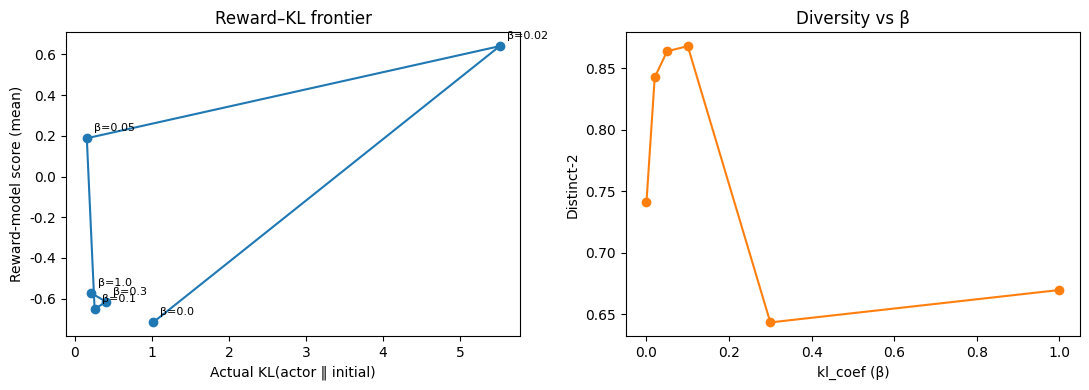

In [43]:
# ============================================================
# [신규] Reward-KL frontier plot (Ziegler et al. 2019 / Ouyang et al. 2022 스타일)
#   + beta vs distinct-2 다양성 곡선
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(df['kl_mean'], df['reward_mean'], 'o-')
for _, row in df.iterrows():
    axes[0].annotate(f"β={row['kl_coef']}", (row['kl_mean'], row['reward_mean']),
                      textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[0].set_xlabel('Actual KL(actor ‖ initial)')
axes[0].set_ylabel('Reward-model score (mean)')
axes[0].set_title('Reward–KL frontier')

axes[1].plot(df['kl_coef'], df['distinct2'], 'o-', color='tab:orange')
axes[1].set_xlabel('kl_coef (β)')
axes[1].set_ylabel('Distinct-2')
axes[1].set_title('Diversity vs β')

plt.tight_layout()
plt.savefig(os.path.join(ppo_result_path, 'kl_sweep_plots.png'), dpi=150)
plt.show()

위 코드블럭의 원본 코드는 KoChatGPT/colossalai_ChatGPT_230319/chatgpt/trainer 폴더 내의 ppo.py 모듈에서 확인할 수 있습니다.  
PPO는 SFT, RM 보다 훨씬 복잡한 단계로 설계되는 강화학습 알고리즘입니다.  
PPO의 loss function은 KoChatGPT/colossalai_ChatGPT_230319/chatgpt/models 폴더 내의 loss.py 모듈에서 PolicyLoss와 ValueLoss 클래스에 정의되어 있습니다.

PPO에 대해 좀 더 자세히 알고 싶으신 분들은 허깅페이스에서 제공하는 [Deep RL Course](https://huggingface.co/learn/deep-rl-course/unit8/introduction?fw=pt)를 참고하세요.

이제 PPO 학습을 진행하도록 하겠습니다.

드디어 SFT, RM 그리고 PPO 학습이 모두 완료되었습니다.
RLHF가 적용된 koGPT-2의 생성능력을 확인해볼까요?

In [44]:
best_actor_model = AutoModelForCausalLM.from_pretrained(BEST_SAVE_DIR).to(device)

# ── 토크나이저: 생성 직전 재로드 + 기능 가드 (한글 깨짐 방지) ──
# 앞선 SFT/RM/PPO 셀에서 tokenizer가 AutoTokenizer로 여러 번 재할당되므로,
# 생성 직전에 KoGPT2 fast 토크나이저로 다시 고정한다.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2',
    bos_token='</s>', eos_token='</s>', unk_token='<unk>',
    pad_token='<pad>', mask_token='<mask>')

# 위 로드가 여전히 GPT-2(vocab 50257)로 가로채이면 아래 주입 방식으로 교체:
# from huggingface_hub import hf_hub_download
# from tokenizers import Tokenizer
# core = Tokenizer.from_file(hf_hub_download('skt/kogpt2-base-v2', 'tokenizer.json'))
# tokenizer = PreTrainedTokenizerFast(tokenizer_object=core,
#     bos_token='</s>', eos_token='</s>', unk_token='<unk>',
#     pad_token='<pad>', mask_token='<mask>')

_s = '불고기용 고기 한우에요?'
_rt = tokenizer.decode(tokenizer.encode(_s))
assert tokenizer.vocab_size == 51200, f"vocab={tokenizer.vocab_size}"
assert '�' not in _rt and '불고기' in _rt, repr(_rt)
print('[tokenizer-guard] KoGPT2 OK - vocab', tokenizer.vocab_size)


def generation(input_text, model):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(torch.cuda.current_device())
    outputs = model.generate(input_ids,
                             max_length=250,
                             do_sample=True,
                             top_k=50,
                             top_p=0.95,
                             num_return_sequences=1,
                             bad_words_ids=None,
                             pad_token_id=tokenizer.pad_token_id,
                             eos_token_id=tokenizer.eos_token_id)

    # BPE 계열은 clean_up_tokenization_spaces=False 가 안전 (True는 무시/파괴적)
    output = tokenizer.decode(outputs[0], skip_special_tokens=True, clean_up_tokenization_spaces=False)

    print(f"\n결과: {output}")
    return output

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어',
    '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt': tmp}) for tmp in list_prompt]

for input_text in list_prompt:
    output = generation(input_text, best_actor_model)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[tokenizer-guard] KoGPT2 OK - vocab 51200

결과: ### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 AI 어시스턴트이기 때문에 실제로 고기를 판매하지 않습니다. 하지만 일반적으로 불고기용 고기는 한우의 크기가 크거나 적은 부위들로 구성되어 있습니다. 따라서 한우에 대한 상세한 정보를 원하시면 관련 제품을 찾아보시는 것을 추천드립니다.

결과: ### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'리처드 닉슨이 37대 부통령직을 수행한 년도는 1954년입니다.

결과: ### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어

### Response(응답):'시카고 오헤어 국제공항은 미국 캘리포니아주 샌프란시스코에 위치해 있습니다.

결과: ### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):'저는 AI 챗봇이므로, 미세먼지에 대한 정보를 알지 못합니다. 그러나 보통 공기 질이 좋지 않은 날에는 실내 미세먼지가 매우 많아질 수 있습니다. 따라서 공기 질을 좋게 유지하기 위해서는 꾸준한 운동과 올바른 식습관 등으로 미세먼지의 수분을 지켜보는 것이 좋습니다.


# 연구 결과 정리

